# EDA(Exploratory Data Analysis) 

Exploratory Data Analysis (EDA) is the process of examining, summarizing, and understanding a dataset before applying models or making conclusions.

Introduction

The dataset used in this project contains information about different traffic violations recorded from drivers. This dataset helps in understanding driver behavior and the factors associated with traffic violations.
By analyzing this dataset using Exploratory Data Analysis (EDA), we can identify common violations, examine patterns among drivers, and study how different factors such as vehicle type or previous violations relate to traffic offenses. The analysis provides useful insights into traffic violation trends and helps in understanding road safety issues.

In [2]:
#IMPORT NECESSARY LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("C:/Users/HP/Downloads/Indian_Traffic_Violations.csv")
df.head()

,Violation_ID,Violation_Type,Fine_Amount,Location,Date,Time,Vehicle_Type,Vehicle_Color,Vehicle_Model_Year,Registration_State,...,Speed_Limit,Recorded_Speed,Alcohol_Level,Breathalyzer_Result,Towed,Fine_Paid,Payment_Method,Court_Appearance_Required,Previous_Violations,Comments
0,VLT100000,Overloading,4544,Karnataka,2023-01-01,23:02,Car,Red,2012,West Bengal,...,100,95,0.03,Negative,Yes,No,Online,Yes,3,Repeat Offender
1,VLT100001,Driving Without License,2776,Punjab,2023-01-02,00:42,Scooter,Silver,2010,Tamil Nadu,...,40,48,0.45,Negative,Yes,Yes,Online,No,2,Repeat Offender
2,VLT100002,Using Mobile Phone,4785,Maharashtra,2023-01-03,04:32,Scooter,Grey,2006,Tamil Nadu,...,80,26,0.31,Not Conducted,No,No,Not Paid,Yes,4,NaN
3,VLT100003,No Seatbelt,1138,Uttar Pradesh,2023-01-04,15:06,Car,Green,1996,Uttar Pradesh,...,100,115,0.09,Not Conducted,No,Yes,Online,No,5,Repeat Offender
4,VLT100004,Over-speeding,1610,Karnataka,2023-01-05,06:57,Truck,Yellow,2016,Delhi,...,30,115,0.28,Positive,No,Yes,Cash,Yes,0,NaN


In [3]:
# Column Name Standardization
# → Replaces hyphens - with underscores _
df.columns=df.columns.str.replace("-","_")
# → Replaces spaces with underscores.
df.columns=df.columns.str.replace(" ","_")
# → Capitalizes the first letter of each column name.
df.columns=df.columns.str.capitalize()
# → Displays the updated column names.
df.columns


Index(['Violation_id', 'Violation_type', 'Fine_amount', 'Location', 'Date',
       'Time', 'Vehicle_type', 'Vehicle_color', 'Vehicle_model_year',
       'Registration_state', 'Driver_age', 'Driver_gender', 'License_type',
       'Penalty_points', 'Weather_condition', 'Road_condition', 'Officer_id',
       'Issuing_agency', 'License_validity', 'Number_of_passengers',
       'Helmet_worn', 'Seatbelt_worn', 'Traffic_light_status', 'Speed_limit',
       'Recorded_speed', 'Alcohol_level', 'Breathalyzer_result', 'Towed',
       'Fine_paid', 'Payment_method', 'Court_appearance_required',
       'Previous_violations', 'Comments'],
      dtype='object')

In [4]:
# Find the missing values and Replace the values
df.isnull().sum()

Violation_id                    0
Violation_type                  0
Fine_amount                     0
Location                        0
Date                            0
Time                            0
Vehicle_type                    0
Vehicle_color                   0
Vehicle_model_year              0
Registration_state              0
Driver_age                      0
Driver_gender                   0
License_type                    0
Penalty_points                  0
Weather_condition               0
Road_condition                  0
Officer_id                      0
Issuing_agency                  0
License_validity                0
Number_of_passengers            0
Helmet_worn                  1349
Seatbelt_worn                1292
Traffic_light_status            0
Speed_limit                     0
Recorded_speed                  0
Alcohol_level                   0
Breathalyzer_result             0
Towed                           0
Fine_paid                       0
Payment_method

In [ ]:
# The columns Helmet_worn, Seatbelt_worn have null values fill with "unknown"
df['Helmet_worn'] = df['Helmet_worn'].fillna('Unknown')
df['Seatbelt_worn'] = df['Seatbelt_worn'].fillna('Unknown')
# verify the columns having null values 
df[['Helmet_worn', 'Seatbelt_worn']].isnull().sum()

Helmet_worn      0
Seatbelt_worn    0
dtype: int64

In [6]:
#  3. Basic Dataset Information
# ===============================
print("Shape of dataset:", df.shape)


Shape of dataset: (4000, 33)


In [7]:
# Comments is not use in the dataset full of null values
df.dropna(subset=['Comments'], inplace=True)

In [8]:
# print all columns
df.columns

Index(['Violation_id', 'Violation_type', 'Fine_amount', 'Location', 'Date',
       'Time', 'Vehicle_type', 'Vehicle_color', 'Vehicle_model_year',
       'Registration_state', 'Driver_age', 'Driver_gender', 'License_type',
       'Penalty_points', 'Weather_condition', 'Road_condition', 'Officer_id',
       'Issuing_agency', 'License_validity', 'Number_of_passengers',
       'Helmet_worn', 'Seatbelt_worn', 'Traffic_light_status', 'Speed_limit',
       'Recorded_speed', 'Alcohol_level', 'Breathalyzer_result', 'Towed',
       'Fine_paid', 'Payment_method', 'Court_appearance_required',
       'Previous_violations', 'Comments'],
      dtype='object')

In [9]:
# To get a quick summary of a DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3004 entries, 0 to 3997
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Violation_id               3004 non-null   object 
 1   Violation_type             3004 non-null   object 
 2   Fine_amount                3004 non-null   int64  
 3   Location                   3004 non-null   object 
 4   Date                       3004 non-null   object 
 5   Time                       3004 non-null   object 
 6   Vehicle_type               3004 non-null   object 
 7   Vehicle_color              3004 non-null   object 
 8   Vehicle_model_year         3004 non-null   int64  
 9   Registration_state         3004 non-null   object 
 10  Driver_age                 3004 non-null   int64  
 11  Driver_gender              3004 non-null   object 
 12  License_type               3004 non-null   object 
 13  Penalty_points             3004 non-null   int64  
 1

In [10]:
# To generate statistical summaries of numerical columns in a DataFrame.
df.describe()

,Fine_amount,Vehicle_model_year,Driver_age,Penalty_points,Number_of_passengers,Speed_limit,Recorded_speed,Alcohol_level,Previous_violations
count,3004.000000,3004.000000,3004.000000,3004.000000,3004.000000,3004.000000,3004.000000,3004.000000,3004.000000
mean,2536.412450,2008.990013,46.701731,4.985020,3.005326,60.093209,69.563915,0.251019,2.482690
std,1421.366623,8.304032,16.916897,3.154915,1.412083,23.691700,29.435870,0.144532,1.714184
min,100.000000,1995.000000,18.000000,0.000000,1.000000,30.000000,20.000000,0.000000,0.000000
25%,1284.000000,2002.000000,32.000000,2.000000,2.000000,40.000000,43.000000,0.120000,1.000000
50%,2511.500000,2009.000000,47.000000,5.000000,3.000000,60.000000,70.000000,0.250000,2.000000
75%,3751.750000,2016.000000,62.000000,8.000000,4.000000,80.000000,95.000000,0.380000,4.000000
max,5000.000000,2023.000000,75.000000,10.000000,5.000000,100.000000,120.000000,0.500000,5.000000


In [11]:
#  DUPLICATES values in the dataset,drop the duplicates values
df.duplicated().sum()
# drop the duplicates 
df.drop_duplicates(inplace=True)

In [12]:
# convert the date and time column in correct format 
df['Time'] = pd.to_datetime(df['Time'].astype(str)).dt.time
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df['Date'].dtype

C:\Users\HP\AppData\Local\Temp\ipykernel_18320\3129735260.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'].astype(str)).dt.time


dtype('<M8[ns]')

In [ ]:
# Correlation shows relationship between numerical variables.
corr_matrix = df.corr(numeric_only=True)#+1 → strong positive
corr_matrix#-1 → strong negative,0 → no relationship

,Fine_amount,Vehicle_model_year,Driver_age,Penalty_points,Number_of_passengers,Speed_limit,Recorded_speed,Alcohol_level,Previous_violations,Speed_Difference
Fine_amount,1.000000,-0.028091,0.005859,0.006668,0.030490,0.011975,-0.025357,0.013554,0.033544,-0.027331
Vehicle_model_year,-0.028091,1.000000,-0.019684,-0.010378,-0.001302,0.021603,0.010824,-0.018703,-0.013066,-0.005126
Driver_age,0.005859,-0.019684,1.000000,-0.021310,0.011372,-0.001285,-0.008455,-0.021249,0.006356,-0.005795
Penalty_points,0.006668,-0.010378,-0.021310,1.000000,-0.010297,0.000687,0.016969,-0.005758,-0.006544,0.012821
Number_of_passengers,0.030490,-0.001302,0.011372,-0.010297,1.000000,0.012427,-0.002724,-0.004840,-0.041646,-0.009939
Speed_limit,0.011975,0.021603,-0.001285,0.000687,0.012427,1.000000,0.005177,-0.000961,0.004468,-0.624548
Recorded_speed,-0.025357,0.010824,-0.008455,0.016969,-0.002724,0.005177,1.000000,-0.008412,-0.051269,0.777742
Alcohol_level,0.013554,-0.018703,-0.021249,-0.005758,-0.004840,-0.000961,-0.008412,1.000000,-0.011999,-0.005965
Previous_violations,0.033544,-0.013066,0.006356,-0.006544,-0.041646,0.004468,-0.051269,-0.011999,1.000000,-0.042849
Speed_Difference,-0.027331,-0.005126,-0.005795,0.012821,-0.009939,-0.624548,0.777742,-0.005965,-0.042849,1.000000


# 10 Question of dataset

 **1. which is the  Most common traffic violation ?**

In [13]:
most_common_violation = df['Violation_type'].value_counts().idxmax()
print("Most common violation:", most_common_violation)

Most common violation: Signal Jumping


 **2.  which is the most highest violations location ?**

In [14]:
top_location = df['Location'].value_counts().idxmax()
print("Location with most violations:", top_location)

Location with most violations: Gujarat


 **3. Number of repeat offenders ?**

In [15]:
repeat_offenders = df[df['Previous_violations'] > 0].shape[0]
print("Number of repeat offenders:", repeat_offenders)


Number of repeat offenders: 2494


**4. how much amount of Percentage is fines paid ?**

In [16]:
fine_paid_percentage = (df['Fine_paid'].value_counts(normalize=True) * 100)
print(fine_paid_percentage)

Fine_paid
No     50.565912
Yes    49.434088
Name: proportion, dtype: float64


**5.Difference between recorded speed and speed limit ?**

In [17]:
df['Speed_Difference'] = df['Recorded_speed'] - df['Speed_limit']
max_speed_violation = df['Speed_Difference'].max()
print("Maximum speed limit violation:", max_speed_violation)

Maximum speed limit violation: 90


**6.Which date had the highest number of violations ?**

In [18]:
df.groupby('Date').size()
df['Date'].value_counts().idxmax()

Timestamp('2033-12-11 00:00:00')

**7. Which day of the week has the most violations ?**

In [19]:

df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df['Date'].dt.day_name().value_counts()

Date
Sunday       455
Saturday     443
Thursday     432
Friday       422
Wednesday    420
Tuesday      417
Monday       415
Name: count, dtype: int64

**8. Fine Paid vs Unpaid ?**

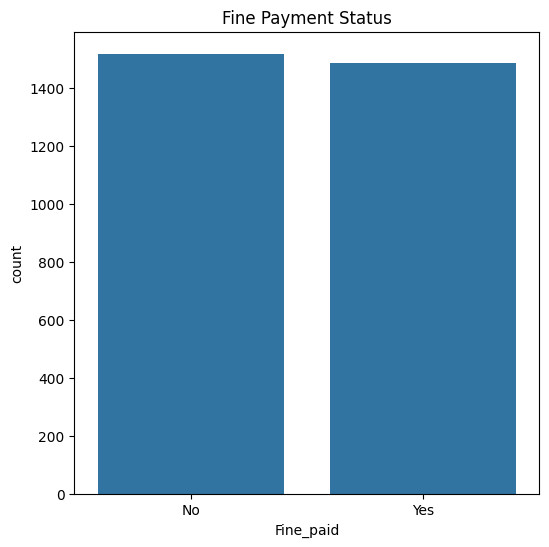

In [20]:
plt.figure(figsize=(6,6))
sns.countplot(x="Fine_paid", data=df)
plt.title("Fine Payment Status")
plt.show()

**9.which vechile type is the highest numbers traffic violations?**

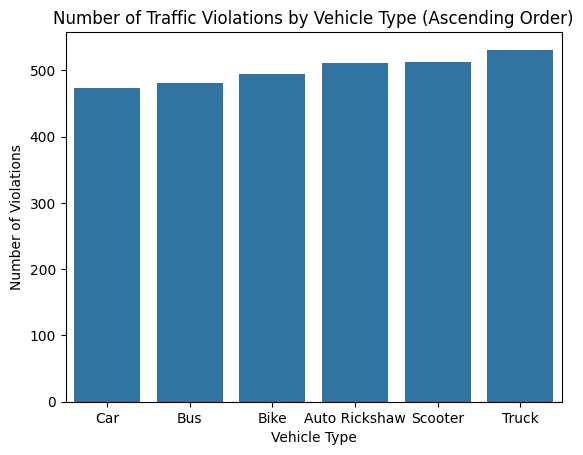

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

order = df['Vehicle_type'].value_counts().sort_values().index

sns.countplot(x='Vehicle_type', data=df, order=order)

plt.title("Number of Traffic Violations by Vehicle Type (Ascending Order)")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Violations")

plt.show()

**10.What percentage of drivers have previous traffic violations ?**

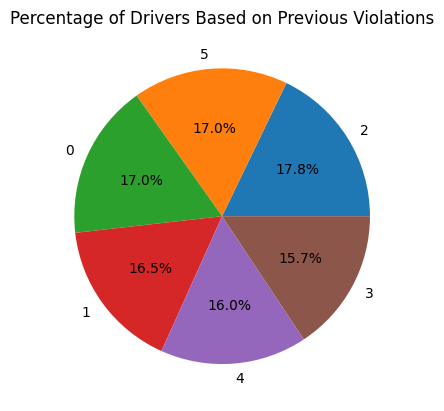

In [22]:
import matplotlib.pyplot as plt

df['Previous_violations'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Percentage of Drivers Based on Previous Violations")
plt.ylabel("")

plt.show()

**11.What percentage of drivers did not wear seatbelts?**

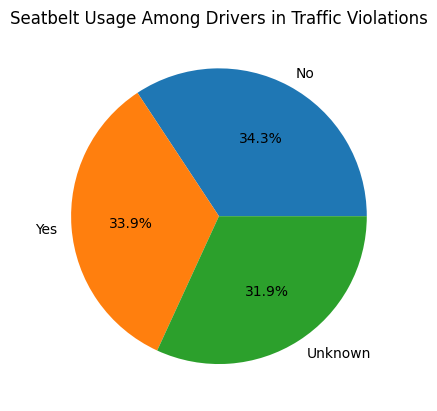

In [23]:
import matplotlib.pyplot as plt

df['Seatbelt_worn'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Seatbelt Usage Among Drivers in Traffic Violations")
plt.ylabel("")

plt.show()

**Conclusion**

In this project, Exploratory Data Analysis (EDA) was performed on the traffic violations dataset to understand patterns and trends related to driver behavior and traffic offenses. The analysis helped identify common types of violations, the vehicles most frequently involved, and other factors such as seatbelt usage, previous violations, and driver characteristics.

By exploring the dataset using statistical methods and visualizations, useful insights were obtained about traffic violation patterns. These findings can help in better understanding road safety issues and highlight the importance of responsible driving and following traffic rules